In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow

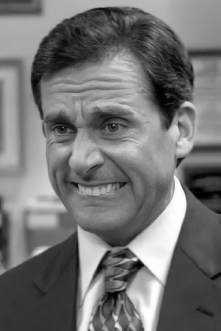

In [ ]:
path = 'scott.jpg'  # Replace with your image path
#load in grayscale
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, None, fx=0.3, fy=0.3, interpolation=cv2.INTER_AREA)
cv2_imshow(img)

In [ ]:
# blurring removes noise and stuff
img = cv2.GaussianBlur(img, (3, 3), 0)

In [ ]:
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

In [ ]:
scharr_x = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]])
scharr_y = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]])

In [ ]:
gx_sobel = cv2.filter2D(img, cv2.CV_64F, sobel_x)
gy_sobel = cv2.filter2D(img, cv2.CV_64F, sobel_y)

gx_scharr = cv2.filter2D(img, cv2.CV_64F, scharr_x)
gy_scharr = cv2.filter2D(img, cv2.CV_64F, scharr_y)

In [ ]:
# take magnitude of the 2 directions and normalize 0-255
mag_sobel = np.sqrt(gx_sobel**2 + gy_sobel**2)
magn_sobel = np.uint8(255 * mag_sobel / np.max(mag_sobel))

mag_scharr = np.sqrt(gx_scharr**2 + gy_scharr**2)
magn_scharr = np.uint8(255 * mag_scharr / np.max(mag_scharr))

(np.float64(-0.5), np.float64(220.5), np.float64(330.5), np.float64(-0.5))

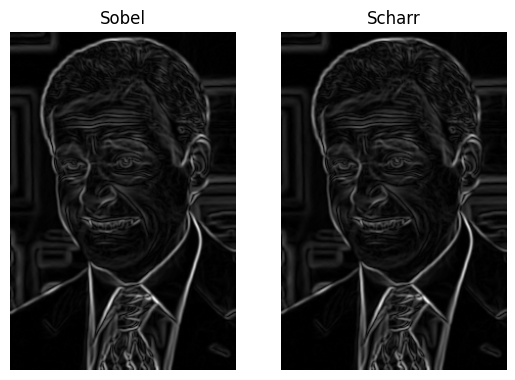

In [ ]:
plt.subplot(1,2,1)
plt.title('Sobel')
plt.imshow(magn_sobel, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Scharr')
plt.imshow(magn_scharr, cmap='gray')
plt.axis('off')

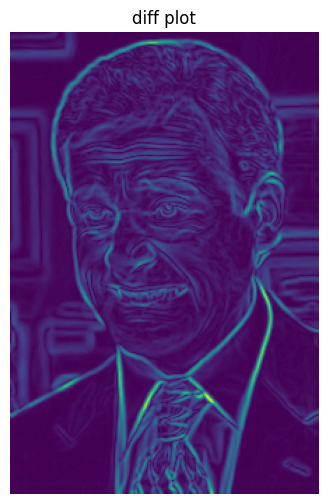

In [ ]:
# diff isn't really visible so explicitly show it
difference = cv2.absdiff(mag_scharr, mag_sobel)
plt.imshow(difference)
plt.title('diff plot')
plt.axis('off')
plt.show()